⏳ Loading target dataset: 'churn-bigml-20.csv'...

⚙️ Training Support Vector Machines (SVM) across varied kernels...

             SVM KERNEL EVALUATION SCORECARD
Kernel Type: LINEAR
 -> Accuracy  : 0.7485
 -> Precision : 0.2632
 -> Recall    : 0.4167
 -> ROC-AUC   : 0.7864
------------------------------------------------------------
Kernel Type: RBF
 -> Accuracy  : 0.8563
 -> Precision : 0.5000
 -> Recall    : 0.5417
 -> ROC-AUC   : 0.8619
------------------------------------------------------------

📊 Compressing 19 dimensions down to a 2D plane for visual graph plotting...


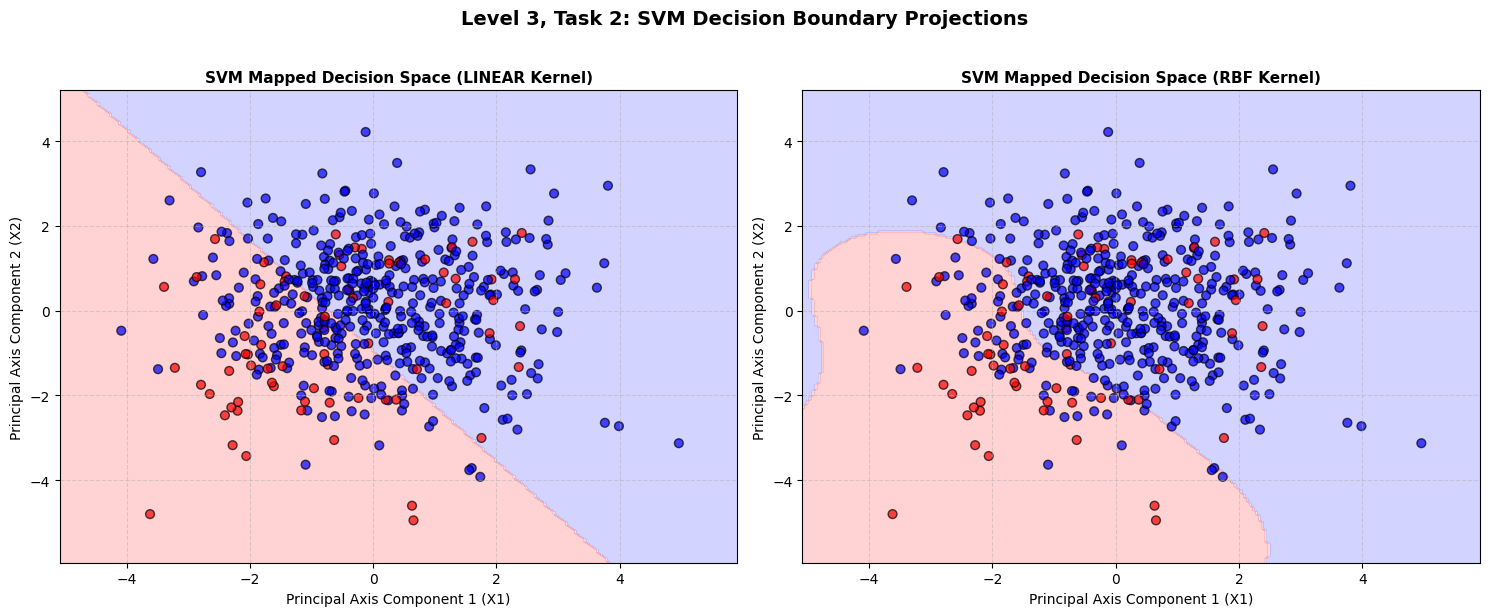

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

# =====================================================================
# 1. DATA INGESTION & ROBUST DATA CHECK
# =====================================================================
filename = 'churn-bigml-20.csv'

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"Missing dataset file '{filename}' in directory '{os.getcwd()}'. "
        f"Please upload your file before running this script."
    )

print(f"⏳ Loading target dataset: '{filename}'...")
df = pd.read_csv(filename)

# Isolate features (X) and binary target (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

# Stratified split to ensure equal churn representation in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# =====================================================================
# 2. FEATURE ENGINEERING PREPROCESSING PIPELINE
# =====================================================================
# SVM is highly sensitive to feature scaling because it relies on geometric distances!
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Transform data safely to prevent structural leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# =====================================================================
# 3. KERNEL COMPARISON: LINEAR VS RBF EXECUTION
# =====================================================================
kernels = ['linear', 'rbf']
performance_metrics = {}
trained_models = {}

print("\n⚙️ Training Support Vector Machines (SVM) across varied kernels...")

for knl in kernels:
    # NOTE: probability=True is required to calculate the syllabus ROC-AUC score!
    # class_weight='balanced' handles your dataset's uneven churn ratio
    svm = SVC(kernel=knl, probability=True, class_weight='balanced', random_state=42)
    svm.fit(X_train_processed, y_train)

    # Make baseline forecasts and pull prediction confidence arrays
    y_pred = svm.predict(X_test_processed)
    y_prob = svm.predict_proba(X_test_processed)[:, 1]

    # Store calculations dynamically
    performance_metrics[knl] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }
    trained_models[knl] = svm

# Display clear terminal performance matrix
print("\n" + "="*60)
print("             SVM KERNEL EVALUATION SCORECARD")
print("="*60)
for knl, scores in performance_metrics.items():
    print(f"Kernel Type: {knl.upper()}")
    print(f" -> Accuracy  : {scores['Accuracy']:.4f}")
    print(f" -> Precision : {scores['Precision']:.4f}")
    print(f" -> Recall    : {scores['Recall']:.4f}")
    print(f" -> ROC-AUC   : {scores['AUC']:.4f}")
    print("-"*60)

# =====================================================================
# 4. DECISION BOUNDARY VISUALIZATION VIA PCA COMPRESSION
# =====================================================================
print("\n📊 Compressing 19 dimensions down to a 2D plane for visual graph plotting...")

# Compress data to 2 components strictly for visualization plotting maps
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)

# Re-fit simple 2D models solely to map boundaries accurately on a flat canvas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Define grid limits across mapped canvas spaces
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

for ax, knl in zip(axes, kernels):
    # Fit visual-only proxy model on the 2D plane points
    visual_svm = SVC(kernel=knl, class_weight='balanced', random_state=42)
    visual_svm.fit(X_train_pca, y_train)

    # Classify coordinate intersections across background mesh grids
    Z = visual_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Draw colored boundary contour zones (Blue = Stayed, Red = Churned risk)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')

    # Scatter active data markers
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,
                         cmap='bwr', edgecolors='k', alpha=0.7, s=40)

    ax.set_title(f"SVM Mapped Decision Space ({knl.upper()} Kernel)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Principal Axis Component 1 (X1)')
    ax.set_ylabel('Principal Axis Component 2 (X2)')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Level 3, Task 2: SVM Decision Boundary Projections", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()